In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import random
random.seed(42)

from nn.activation_functions import sigmoid, sigmoid_deriv
from nn.network import SimpleNetwork
from nn.wrappers import  Identity as MinMaxScaler
#from nn.wrappers import MinMaxScaler
from nn.metrics import mse

In [2]:
def lab2(train_path, test_path, hidden_layers_sizes, epochs, learning_rate, batch_size):

    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)

    X_train = train[['x']].values
    X_test = test[['x']].values
    y_train = train[['y']].values
    y_test = test[['y']].values


    x_scaler = MinMaxScaler()
    X_train_scaled = x_scaler.fit_transform(X_train)
    X_test_scaled = x_scaler.transform(X_test)
    y_scaler = MinMaxScaler()
    y_train_scaled = y_scaler.fit_transform(y_train)

    model = SimpleNetwork(
        input_size=1,
        output_size=1,
        hidden_layers_sizes=hidden_layers_sizes,
        activation_func=sigmoid,
        activation_deriv=sigmoid_deriv,
        init_method="uniform"
    )

    history = model.fit_with_history(X_train_scaled, y_train_scaled, epochs=epochs, learning_rate=learning_rate, batch_size=batch_size)

    y_train_pred = y_scaler.inverse_transform(model.predict(X_train_scaled))
    y_test_pred = y_scaler.inverse_transform(model.predict(X_test_scaled))

    print(f'MSE na nieznormalizowanym zbiorze treningowym : {mse(y_train, y_train_pred):.4f}')
    print(f'MSE na nieznormalizowanym zbiorze testowym    : {mse(y_test, y_test_pred):.4f}')

    # =======================================================
    # --- WIZUALIZACJE ---
    # =======================================================
    num_layers = len(model.layers)
    fig = plt.figure(figsize=(18, 10))

    # --- RZĄD 1: Dopasowanie Train, Dopasowanie Test, Krzywa uczenia (Siatka 2 rzędy x 3 kolumny) ---
    ax_fit_train = fig.add_subplot(2, 3, 1)
    ax_fit_test = fig.add_subplot(2, 3, 2)
    ax_loss = fig.add_subplot(2, 3, 3)

    # Wykres 1: Dopasowanie na zbiorze treningowym
    ax_fit_train.scatter(X_train, y_train, label='Oryginalne dane', color='blue', s=10)
    ax_fit_train.scatter(X_train, y_train_pred, label='Predykcja', color='red', s=10)
    ax_fit_train.set_title("Dopasowanie (Train)")
    ax_fit_train.set_xlabel("x")
    ax_fit_train.set_ylabel("y")
    ax_fit_train.legend()
    ax_fit_train.grid(True, linestyle='--', alpha=0.7)

    # Wykres 2: Dopasowanie na zbiorze testowym
    ax_fit_test.scatter(X_test, y_test, label='Oryginalne dane', color='blue', s=10)
    ax_fit_test.scatter(X_test, y_test_pred, label='Predykcja', color='orange', s=10)
    ax_fit_test.set_title("Dopasowanie (Test)")
    ax_fit_test.set_xlabel("x")
    ax_fit_test.set_ylabel("y")
    ax_fit_test.legend()
    ax_fit_test.grid(True, linestyle='--', alpha=0.7)

    # Wykres 3: Krzywa uczenia (Loss na train)
    ax_loss.plot(history['loss'], color='red', linewidth=2)
    ax_loss.set_title("Krzywa uczenia na Train (MSE)")
    ax_loss.set_xlabel("Epoka")
    ax_loss.set_ylabel("Błąd MSE")
    ax_loss.grid(True, linestyle='--', alpha=0.7)

    # --- RZĄD 2: Zmiany wag dla kolejnych warstw (liczba kolumn = num_layers) ---
    for layer_idx in range(num_layers):
        # Definiujemy podział dla dolnego rzędu na podstawie ilości warstw
        ax_w = fig.add_subplot(2, num_layers, num_layers + layer_idx + 1)
        layer_weights = np.array(history['weights'][layer_idx])

        # Rysujemy linie dla każdego połączenia wag
        for input_idx in range(layer_weights.shape[1]):
            for neuron_idx in range(layer_weights.shape[2]):
                ax_w.plot(layer_weights[:, input_idx, neuron_idx],
                          label=f'w({input_idx}->{neuron_idx})' if layer_weights.shape[1] * layer_weights.shape[2] <= 10 else "")

        title = f"Wagi - Warstwa {layer_idx + 1}"
        if layer_idx == num_layers - 1:
            title += " (Wyjściowa)"
        else:
            title += " (Ukryta)"

        ax_w.set_title(title)
        ax_w.set_xlabel("Epoka")
        ax_w.grid(True, linestyle='--', alpha=0.7)

        # Wyświetlamy legendę tylko jeśli wag nie jest za dużo
        if layer_weights.shape[1] * layer_weights.shape[2] <= 10:
            ax_w.legend()

    plt.tight_layout()
    plt.show()

MSE na nieznormalizowanym zbiorze treningowym : 0.2424
MSE na nieznormalizowanym zbiorze testowym    : 1.0742


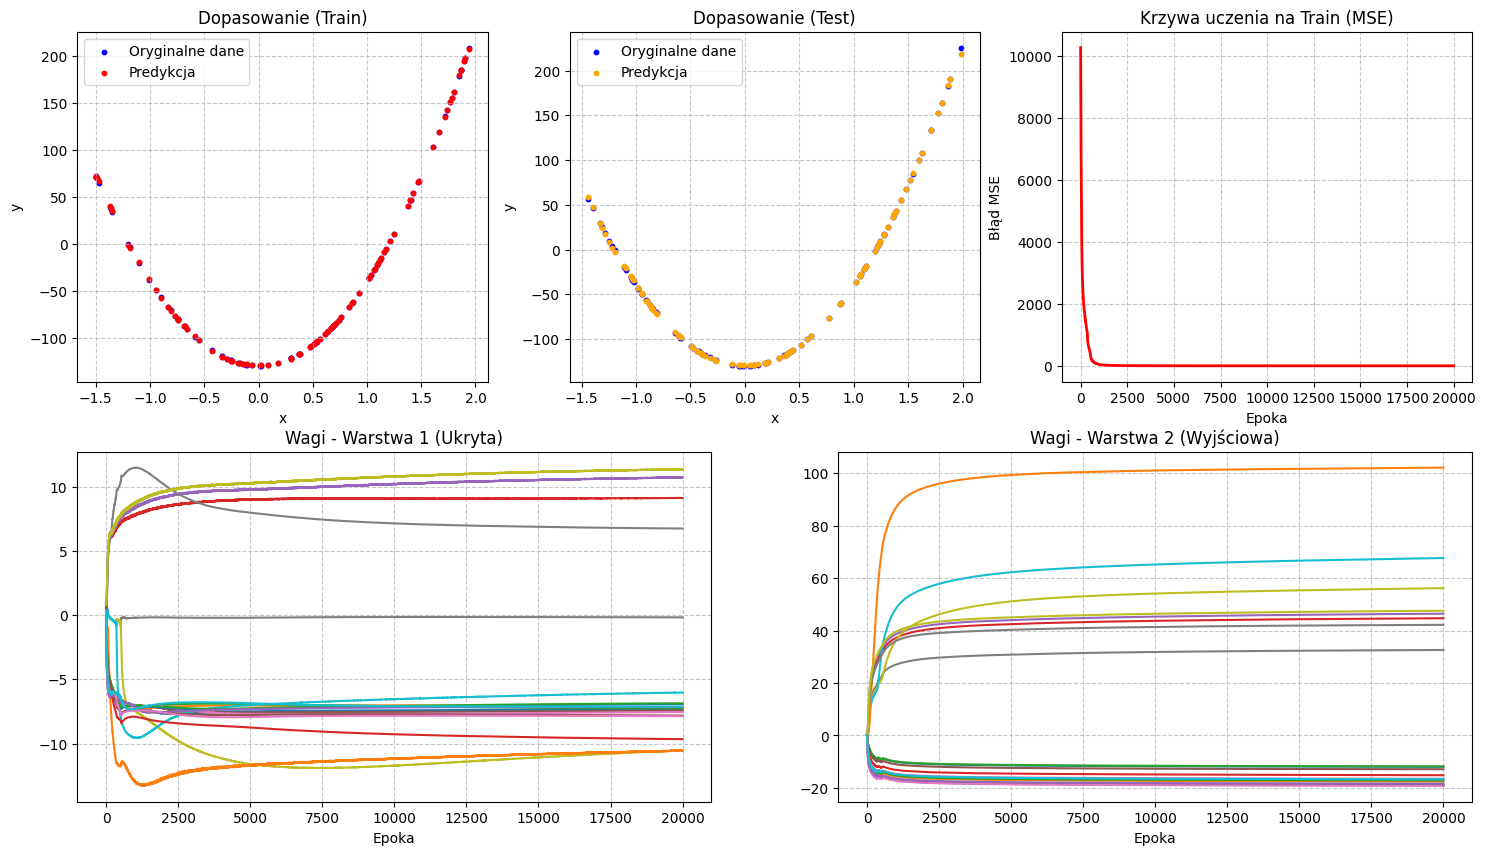

In [3]:
lab2(train_path= 'datasets/regression/square-simple-training.csv',
     test_path= 'datasets/regression/square-simple-test.csv',
     hidden_layers_sizes = [20],
     epochs = 20000,
     learning_rate = 0.001,
     batch_size = 12,
     )

MSE na nieznormalizowanym zbiorze treningowym : 158.9290
MSE na nieznormalizowanym zbiorze testowym    : 97.4582


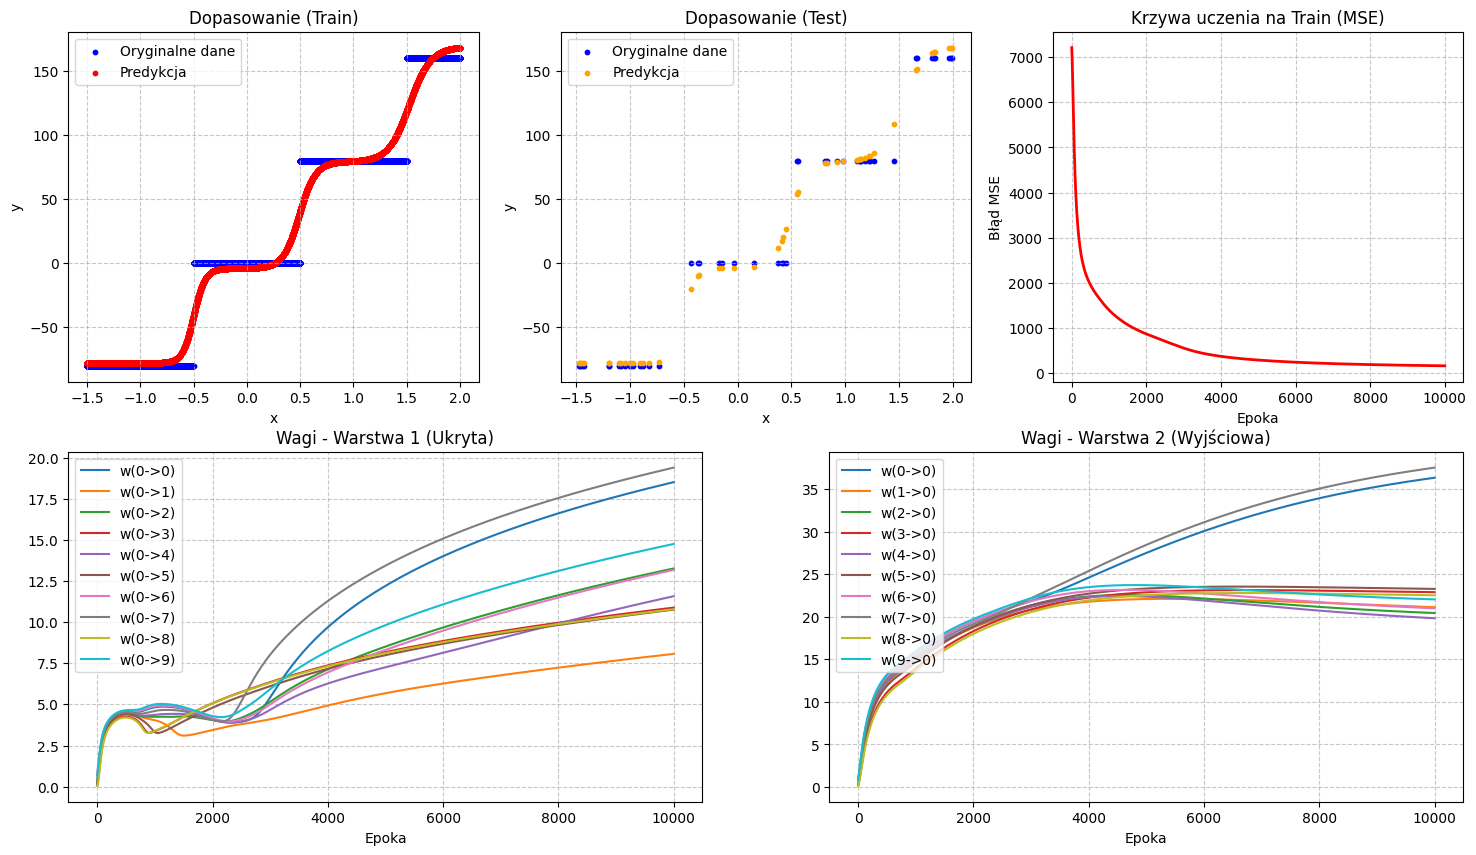

In [44]:
lab2(train_path= 'datasets/regression/steps-large-training.csv',
     test_path= 'datasets/regression/steps-small-test.csv',
     hidden_layers_sizes = [10],
     epochs = 10000,
     learning_rate = 0.001,
     batch_size = None,
     )

MSE na nieznormalizowanym zbiorze treningowym : 8.9106
MSE na nieznormalizowanym zbiorze testowym    : 12.9450


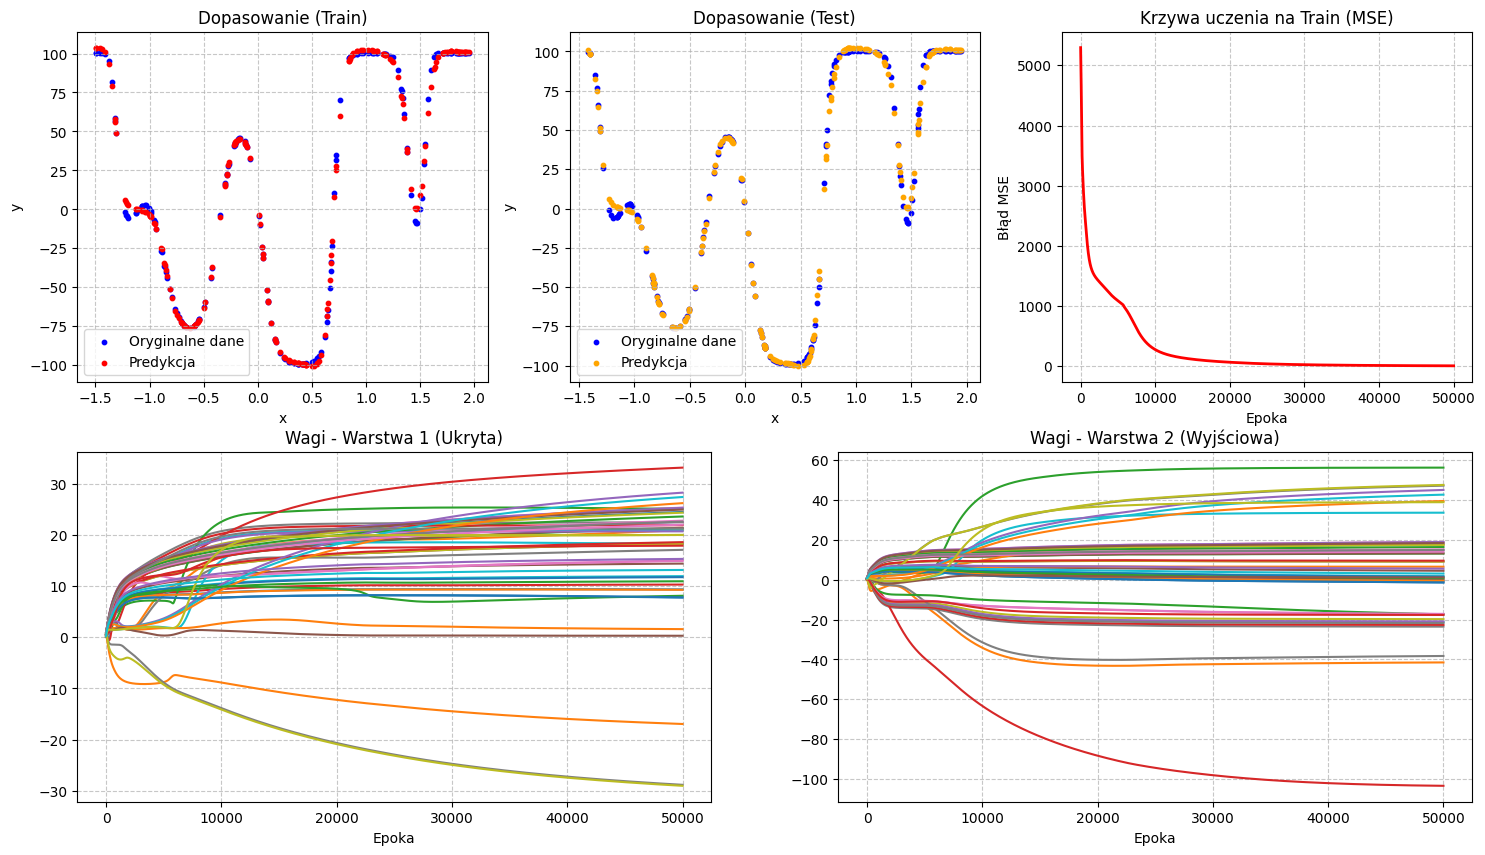

In [5]:
lab2(train_path= 'datasets/regression/multimodal-small-training.csv',
     test_path= 'datasets/regression/multimodal-small-test.csv',
     hidden_layers_sizes = [50],
     epochs = 50000,
     learning_rate = 0.002,
     batch_size = None,
     )

MSE na nieznormalizowanym zbiorze treningowym : 15.0867
MSE na nieznormalizowanym zbiorze testowym    : 10.0342


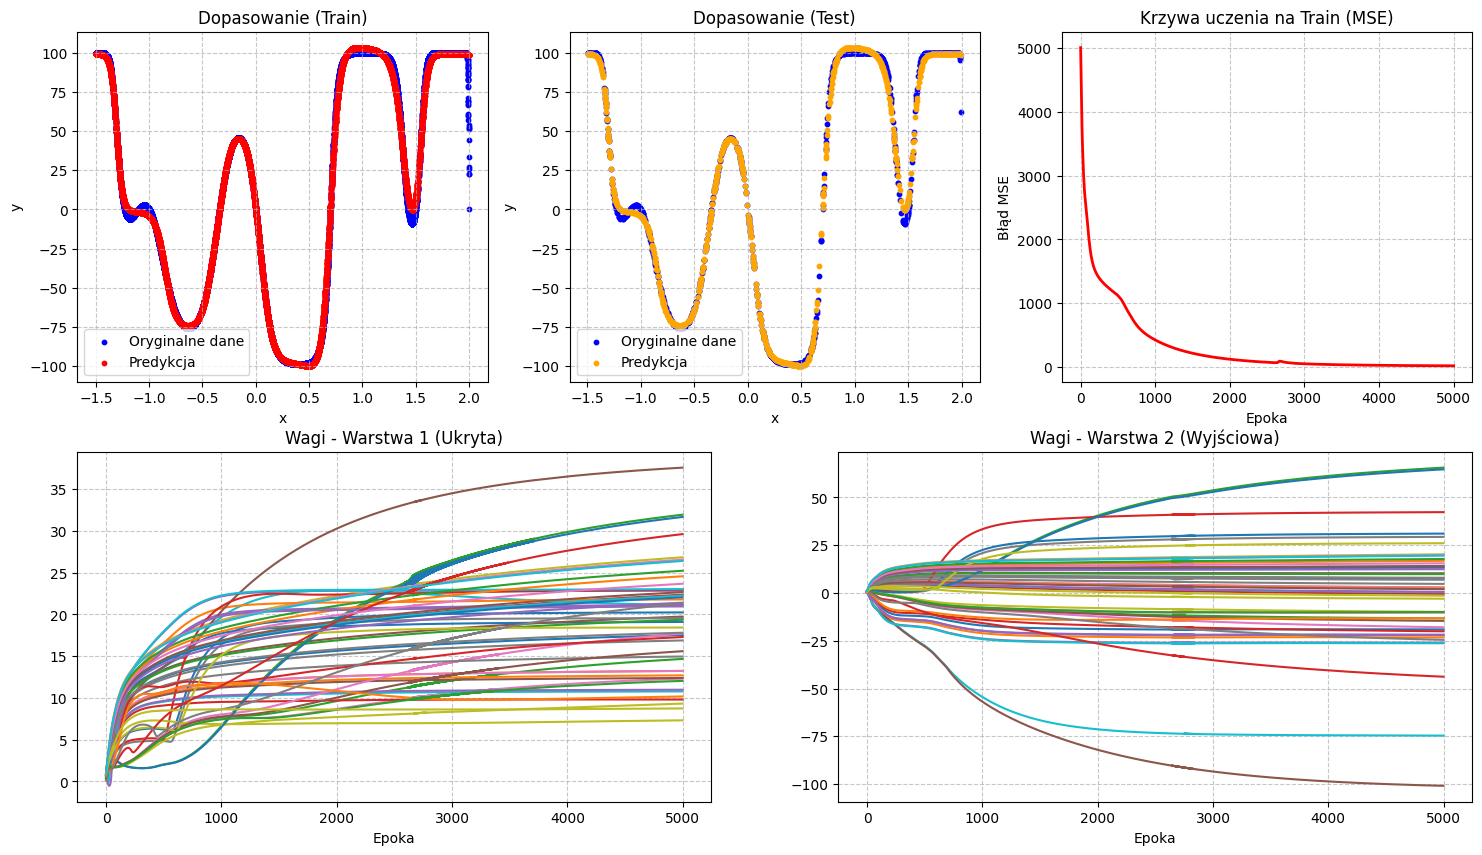

In [6]:
lab2(train_path= 'datasets/regression/multimodal-large-training.csv',
     test_path= 'datasets/regression/multimodal-large-test.csv',
      hidden_layers_sizes = [50],
     epochs = 5000,
     learning_rate = 0.02,
     batch_size = None,
     )